# This is the imputation notebook..
This notebook firstly impute sparsity in air quality indicator. This artificial sparsity is created through block sparsity introduced in the series. When this sparsity is imputed, the Seq2Seq model is then run on this new data with synthetic data points. The errors are compare to the Attention model, which model sparsity directly.

In [106]:

import all_imports as ai 

In [ ]:
# import importlib
# import Seq2Seq_data_prep
# importlib.reload(Seq2Seq_data_prep)


<module 'Seq2Seq_data_prep' from 'c:\\mythesis_work\\Seq2Seq_data_prep.py'>

In [94]:
from Seq2Seq_data_prep import (KalmanImpute, prepare_data, prepare_sequence_data)
from attetion_prepare import (DataPreparationAttention)
from Seq2Se2_baseline import (SequenceToSequenceModel, ForecastPipeline)

In [ ]:
''''  #load the cleaned data'''

data = ai.pd.read_csv("data") 

In [89]:
data.index = ai.pd.to_datetime(data.index)

In [ ]:
data.tail(2)

In [ ]:
def imput_and_process(data, target_col, start_time, end_time, year):
    prep = DataPreparationAttention(data, target_col, start_time, end_time)
    df_sparse, mask_df = prep.apply_block_sparsity(year)
    impute = KalmanImpute(df_sparse, mask_df, target_col, noise_level=0.1)
    imputed = impute.run()

    return imputed

''' This code impute the data based on the type of sparsity that was simulated in the data'''

In [ ]:
CO_imputed = imput_and_process(data, "CO", 1, 7, 2020)
''' Here that sparsity pattern was block (1:00Am-7:00 am for the whole of 2020)'''

In [ ]:
CO_imputed 

In [95]:
''' Takes the configuration of the model'''

config = {
    "input_len": 24,          
    "output_len": 24,         
    "input_features": 18,    
    "target_features": 1,   
    "hidden_size": 128,
    "num_layers": 2,
    "dropout_rate": 0.3,
    "target_index": 0,  
    "deco_input_features": 1,   
    "epochs": 1,           
}

# Check if the pipeline works

In [96]:
# del(seq2seq_model)
(X_enc_train, X_dec_train, Y_train,
 X_enc_val, X_dec_val, Y_val,
 X_enc_test, X_dec_test, Y_test,
 scalers_test, target_column_name, output_seq_len) = prepare_sequence_data(CO_imputed, input_seq_len=config["input_len"], output_seq_len=config["output_len"], target_indices=[0], split_ratio=(0.7, 0.85))

287/287 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - loss: 11.3008 - mae: 0.8691 - val_loss: 603159.3750 - val_mae: 3.1662

📊 Evaluation on Inverse-Transformed Test Set:
MAE   = 3.2690
MAPE  = 22.9639%
SMAPE = 19.6249%
MSE   = 18.8901
RMSE  = 4.3463
Sparsity_level: imputed_Fh_48_


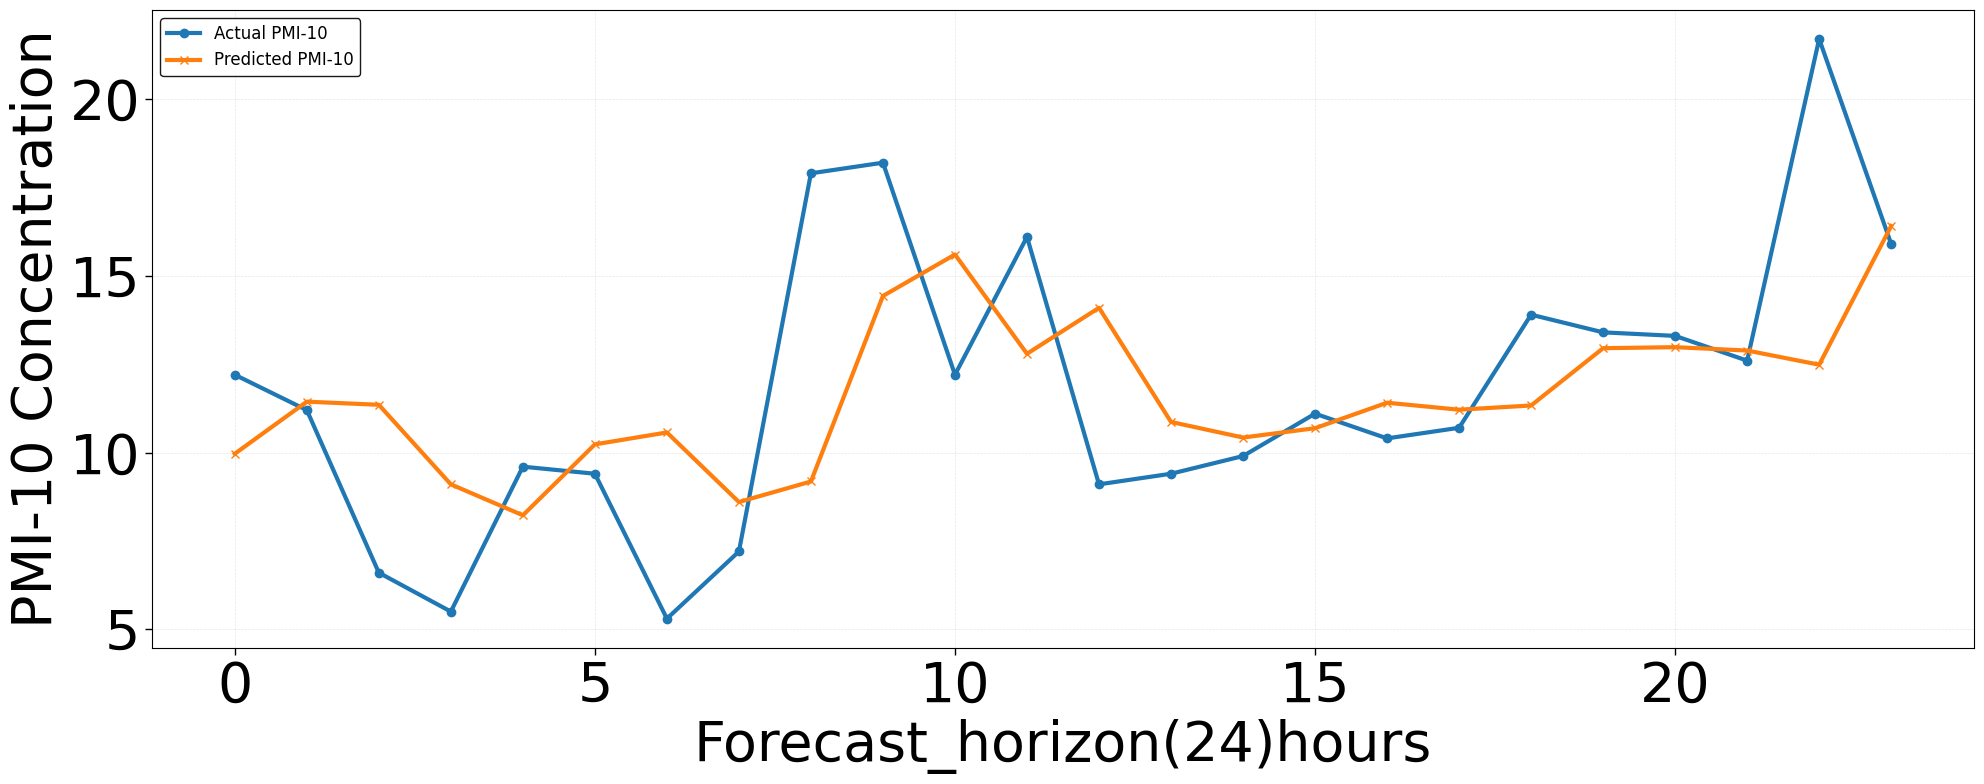

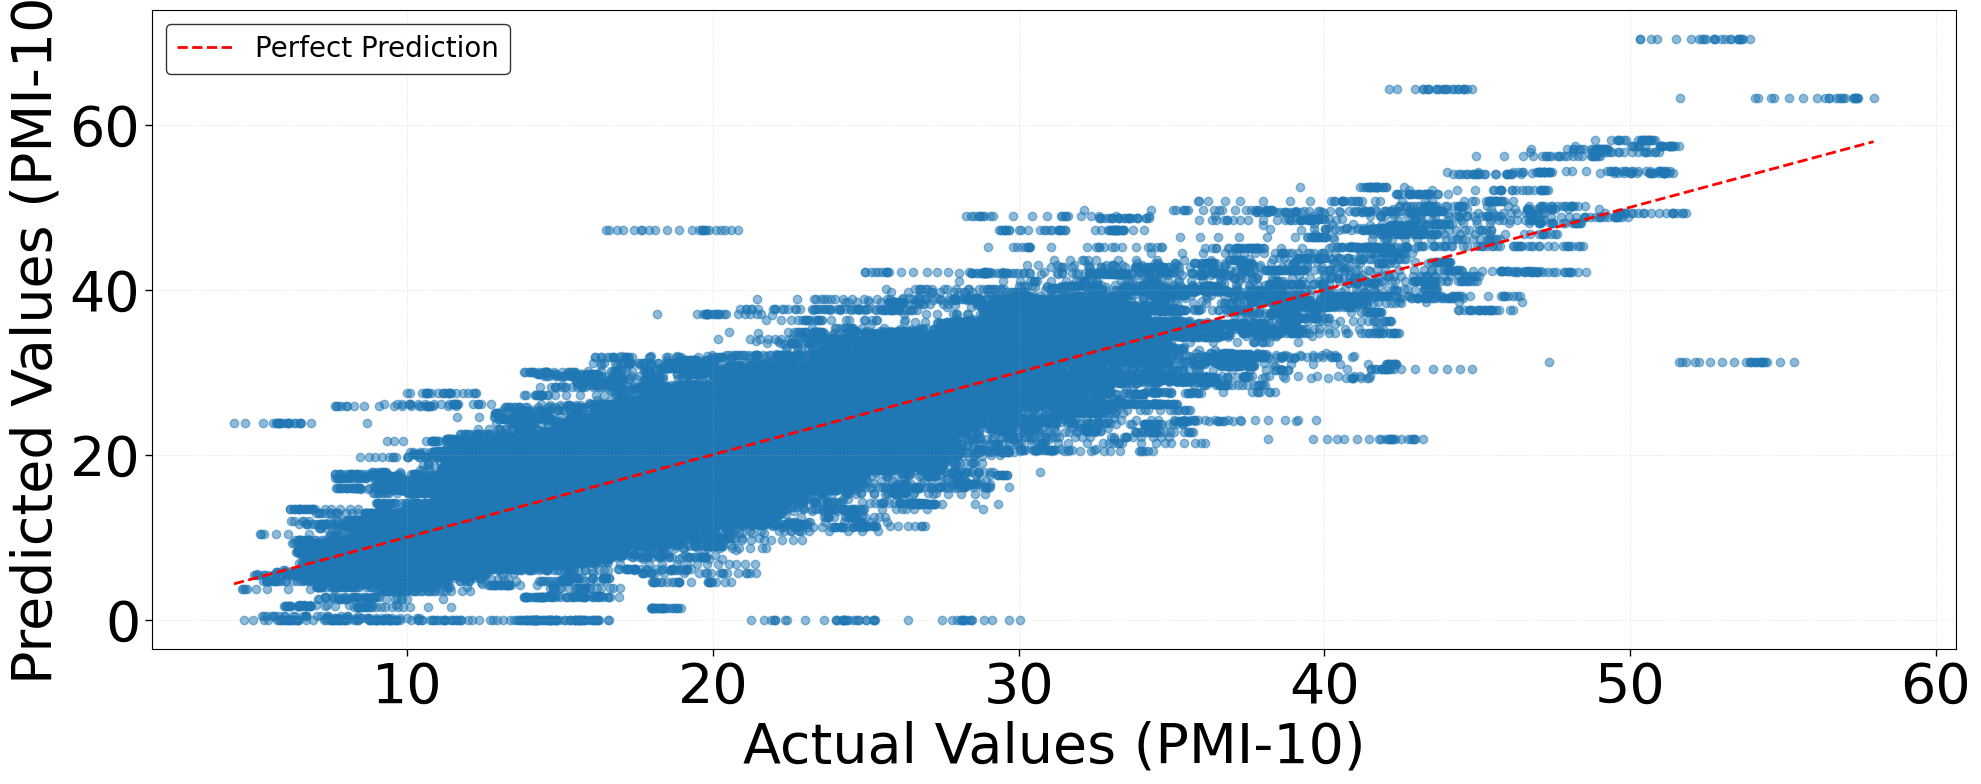

In [97]:
model = SequenceToSequenceModel(enc_units=64, dec_units=64, output_dim=1, dropout_rate=0.3)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

pipeline = ForecastPipeline(model, sparsity_level="imputed_Fh_48_", scaler_list=scalers_test)

# Traindsfjdsjsadkd

history = pipeline.train_model(X_enc_train, X_dec_train, Y_train,
                             X_enc_val, X_dec_val, Y_val,
                               batch_size=64, epochs=1, patience=5)

# Evaluate
Y_true, Y_pred = pipeline.evaluate_model(X_enc_test, X_dec_test, Y_test)

# Metrics
metrices = pipeline.compute_metrics(Y_true, Y_pred, target_column_name)
#save_path= f"results_plot/forecasting_baseline_{target_column_name}_{output_seq_len}
# Plot
pipeline.plot_forecast(Y_true, Y_pred, target_column_name, output_seq_len)
#save_path= f"results_plot/error_ditsri_baseline_{target_column_name}_{output_seq_len}",
pipeline.plot_error_distribution(Y_pred, Y_true, target_column_name,  show_histogram=False)

In [65]:
''' Takes the configuration of the model'''

config = {
    "input_len": 24,          
    "output_len": 48,         
    "input_features": 18,    
    "target_features": 1,   
    "hidden_size": 128,
    "num_layers": 2,
    "dropout_rate": 0.3,
    "target_index": 0,  
    "deco_input_features": 1,   
    "epochs": 1,           
}

In [98]:
def objective(trial):
    # 📊 Sample hyperparameters
    config = {"enc_units": trial.suggest_int("enc_units", 32, 128),
              "dec_units" :trial.suggest_int("dec_units", 32, 128),
              "dropout_rate": trial.suggest_float("dropout_rate", 0.1, 0.5),
              "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
              "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
              "epochs": trial.suggest_int("epochs", 1, 2)}
   

    # 🧠 Build model
    model = SequenceToSequenceModel(
        enc_units=config["enc_units"],
        dec_units=config["dec_units"],
        output_dim=1,
        dropout_rate=config["dropout_rate"]
    )
    model.compile(optimizer=ai.tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
                  loss='mse', metrics=['mae'])

    # 🔁 Train
    pipeline = ForecastPipeline(model, scaler_list=scalers_test)
    history = pipeline.train_model(
        X_enc_train, X_dec_train, Y_train,
        X_enc_val, X_dec_val, Y_val,
        batch_size=config["batch_size"],
        epochs=config["epochs"],
        patience=5
    )
    

    # 📉 Evaluate on validation set
    val_loss = min(history.history['val_mae'])  # or 'val_loss' if preferred

    return val_loss

In [102]:
def extract_and_test():
    study_imputed = ai.optuna.create_study(direction="minimize")
    study_imputed.optimize(objective, n_trials=1)
    imputed_best_params = study_imputed.best_trial.params
    best_params_imputed = study_imputed.best_trial.params
    print("Best MAE:", study_imputed.best_trial.value)
    print("Best hyperparameters:", best_params_imputed)


    best_config_imputed = { "best_enc_units": best_params_imputed["enc_units"],
               "best_dec_units": best_params_imputed["dec_units"],
               "best_dropout": best_params_imputed["dropout_rate"],
               "best_lr": best_params_imputed["learning_rate"],
               "best_epoch": best_params_imputed["epochs"], 
               "best_batch_size": best_params_imputed["batch_size"]}
    model = SequenceToSequenceModel(
        enc_units=best_config_imputed["best_enc_units"],
        dec_units=best_config_imputed["best_dec_units"],
        output_dim=1,
        dropout_rate=best_config_imputed["best_dropout"]
        )
    model.compile(
        optimizer=ai.tf.keras.optimizers.Adam(learning_rate=best_config_imputed["best_lr"]),
        loss='mse',
        metrics=['mae']
        )
    
    pipeline = ForecastPipeline(model, sparsity_level="imputed_origin_48_FH", scaler_list=scalers_test)
    
    history = pipeline.train_model(
        X_enc_train, X_dec_train, Y_train,
        X_enc_val, X_dec_val, Y_val,
        batch_size=best_config_imputed["best_batch_size"],
        epochs=best_config_imputed["best_epoch"],
        patience=5
    )

    return model, best_params_imputed

In [103]:
model, best_params_imputed = extract_and_test()



[I 2025-11-20 20:34:51,065] A new study created in memory with name: no-name-a8fd035b-1d89-406d-a60f-ab44008a66de


Epoch 1/2
287/287 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - loss: 10.9042 - mae: 0.6942 - val_loss: 603159.1250 - val_mae: 3.1468
Epoch 2/2
287/287 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - loss: 10.7137 - mae: 0.6056 - val_loss: 603158.6875 - val_mae: 3.1416


[I 2025-11-20 20:35:34,770] Trial 0 finished with value: 3.141627073287964 and parameters: {'enc_units': 100, 'dec_units': 42, 'dropout_rate': 0.39418609875338484, 'learning_rate': 0.007916123499470193, 'batch_size': 64, 'epochs': 2}. Best is trial 0 with value: 3.141627073287964.


Best MAE: 3.141627073287964
Best hyperparameters: {'enc_units': 100, 'dec_units': 42, 'dropout_rate': 0.39418609875338484, 'learning_rate': 0.007916123499470193, 'batch_size': 64, 'epochs': 2}
Epoch 1/2
287/287 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - loss: 10.9227 - mae: 0.7041 - val_loss: 603159.3750 - val_mae: 3.1487
Epoch 2/2
287/287 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - loss: 10.7012 - mae: 0.6008 - val_loss: 603158.0625 - val_mae: 3.1396



📊 Evaluation on Inverse-Transformed Test Set:
MAE   = 3.2690
MAPE  = 22.9639%
SMAPE = 19.6249%
MSE   = 18.8901
RMSE  = 4.3463
Sparsity_level: imputed_model_origin_48_FH


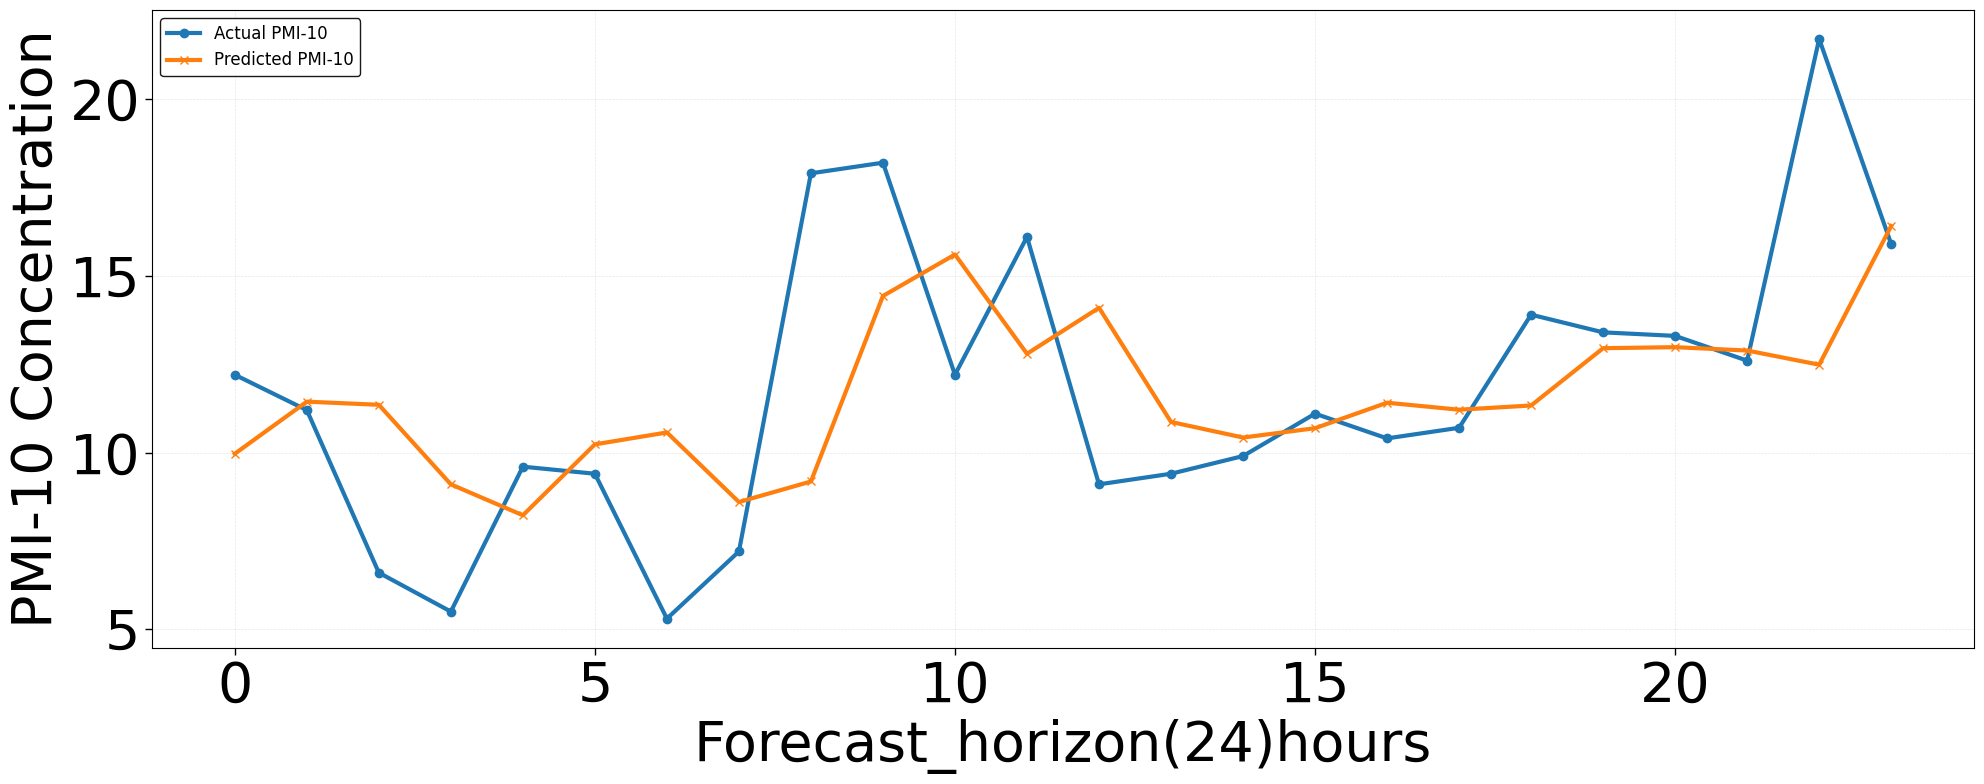

c:\mythesis_work\Seq2Se2_baseline.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=20, loc='upper left', frameon=True, framealpha=0.8)


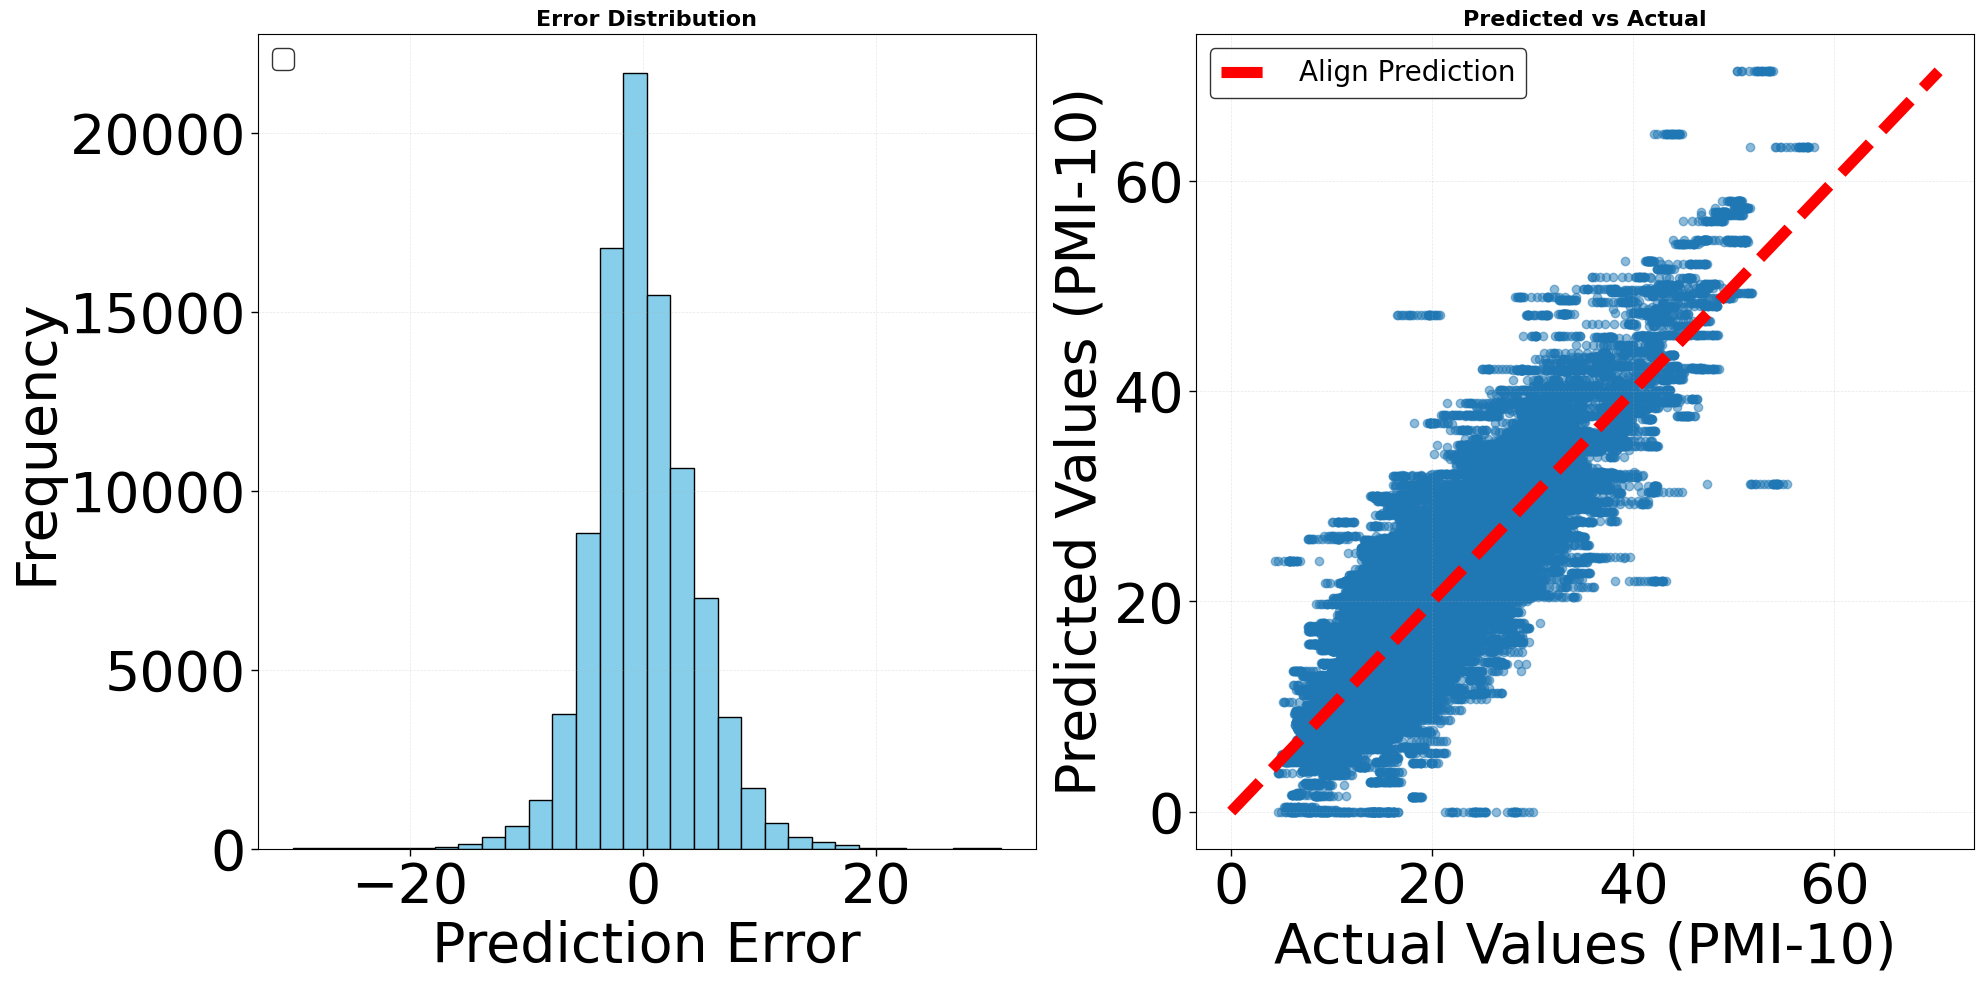

In [104]:
pipeline_imputed = ForecastPipeline(model, sparsity_level="imputed_model_origin_48_FH", scaler_list=scalers_test)
Y_true, Y_pred = pipeline.evaluate_model(X_enc_test, X_dec_test, Y_test)
# pipeline.compute_metrics(Y_true, Y_pred)
# pipeline.plot_forecast(Y_true, Y_pred, target_column_name)
# pipeline.plot_error_distribution(Y_true, Y_pred, target_column_name, show_histogram=False)
# Metrics
metrices_imputed = pipeline_imputed.compute_metrics(Y_true, Y_pred, target_column_name)

# Plot
# save_path= f"results_plot/forecasting_baseline_{target_column_name}_{output_seq_len}"

pipeline_imputed.plot_forecast(Y_true, Y_pred, target_column_name, output_seq_len)

pipeline_imputed.plot_error_distribution(Y_pred, Y_true, target_column_name)

#save_path= f"results_plot/error_ditsri_baseline_{target_column_name}_{output_seq_len}"
# pipeline.plot_training_history(history, highlight_best=True, smooth=True)

In [ ]:
combined_imputed = {**metrices_imputed, **best_params_imputed} # Merge both dictionaries
# results_baseline = ai.pd.DataFrame.from_dict(combined_baseline, orient="index").T 
# results_baseline.to_csv("baseline.csv", index=False)

In [76]:
imputed = ai.pd.DataFrame.from_dict(combined_imputed, orient="index").T
imputed.to_csv("baseline.csv", mode="a", header=False, index=False)

In [107]:
imputed = ai.pd.read_csv("baseline.csv")
